## **Overview**

This notebook implements the final **cross-disaster Model 2** pipeline for building damage assessment on **xBD**.

The model is a **bi-temporal end-to-end segmentation network** trained under a stricter **held-out disaster** setting, where one disaster type is excluded from training and used only for testing. It takes paired pre- and post-disaster images as input and predicts a dense **5-class damage map**:
- background
- no-damage
- minor-damage
- major-damage
- destroyed

The notebook includes:
- local data preparation for efficient Colab execution
- cross-disaster split loading
- localization pretraining on binary building masks
- encoder transfer into the damage model
- damage-aware crop selection for training
- full-tile tiled inference and evaluation
- building-level assessment derived from the predicted masks

This notebook is used to evaluate how well the **bi-temporal end-to-end model generalizes to an unseen disaster type** and to compare its behavior with the two-step pipeline under the same cross-disaster setting.

## **Environment Setup**

Install required libraries, import dependencies, and mount Google Drive for dataset access and checkpoint storage.

In [ ]:
!pip -q install albumentations
!pip -q install timm

In [ ]:
import random
from pathlib import Path
import os

import cv2
import json
import re
import numpy as np
import pandas as pd
from PIL import Image
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from collections import Counter
from tqdm.auto import tqdm

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, classification_report

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## **Prepare Local Working Directory**

Copy the xBD archive and metadata to the local Colab runtime to reduce Drive I/O overhead and speed up training.

In [ ]:
DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/xBD_project")
LOCAL_ROOT = Path("/content/xbd_work")
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

TAR_PATH = DRIVE_PROJECT_ROOT / "train.tar"
LOCAL_TAR_PATH = LOCAL_ROOT / "train.tar"
LOCAL_TRAIN_ROOT = LOCAL_ROOT / "train"

DRIVE_META_ROOT = DRIVE_PROJECT_ROOT / "output" / "metadata"
LOCAL_META_ROOT = LOCAL_ROOT / "metadata"

print("Copying train.tar to /content ...")
os.system(f'cp "{TAR_PATH}" "{LOCAL_TAR_PATH}"')

print("Extracting train.tar ...")
os.system(f'tar -xf "{LOCAL_TAR_PATH}" -C "{LOCAL_ROOT}"')

print("Copying metadata...")
os.system(f'rsync -ah "{DRIVE_META_ROOT}/" "{LOCAL_META_ROOT}/"')

print("Local data is ready.")

Copying train.tar to /content ...
Extracting train.tar ...
Copying metadata...
Local data is ready.


## **Configuration**

Define dataset paths, random seeds, training hyperparameters, and class settings used throughout the notebook.

In [ ]:
LOCAL_ROOT = Path("/content/xbd_work")
DATA_ROOT = LOCAL_ROOT / "train"
META_ROOT = LOCAL_ROOT / "metadata"

SPLIT_CSV = META_ROOT / "cross_disaster_split.csv" # Held-out disaster type: wind
PAIRS_CSV = META_ROOT / "xbd_pairs_metadata.csv"

NUM_CLASSES = 5
CLASS_NAMES = ["background", "no-damage", "minor-damage", "major-damage", "destroyed"]
CROP_SIZE = 608
TRAIN_PATCH_SIZE = 608
BATCH_SIZE = 16
NUM_WORKERS = 4
LR = 5e-5
EPOCHS = 35
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("DATA_ROOT:", DATA_ROOT)
print("META_ROOT:", META_ROOT)

Device: cuda
DATA_ROOT: /content/xbd_work/train
META_ROOT: /content/xbd_work/metadata


In [ ]:
print((DATA_ROOT / "images").exists())
print((DATA_ROOT / "labels").exists())
print((DATA_ROOT / "targets").exists())

True
True
True


## **Load Metadata and Data Splits**

Load the xBD metadata, merge it with the cross-disaster split file, and convert all paths to local Colab paths.

In [ ]:
pairs_df = pd.read_csv(PAIRS_CSV)
split_df = pd.read_csv(SPLIT_CSV)

split_df = split_df[["sample_id", "split"]].copy()

df = pairs_df.merge(split_df, on="sample_id", how="inner")

def to_colab_path(p):
    p = str(p)
    p = p.replace("\\", "/")

    if "/images/" in p:
        fname = Path(p).name
        return str(DATA_ROOT / "images" / fname)

    if "/labels/" in p:
        fname = Path(p).name
        return str(DATA_ROOT / "labels" / fname)

    if "/targets/" in p:
        fname = Path(p).name
        return str(DATA_ROOT / "targets" / fname)

    return p

df["pre_img"] = df["pre_path"].apply(to_colab_path)
df["post_img"] = df["post_path"].apply(to_colab_path)
df["pre_label_path"] = df["pre_label_path"].apply(to_colab_path)
df["post_label_path"] = df["post_label_path"].apply(to_colab_path)
df["pre_target_path"] = df["pre_target_path"].apply(to_colab_path)
df["post_target_path"] = df["post_target_path"].apply(to_colab_path)
df["mask_path"] = df["post_target_path"]

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

display(train_df[[
    "sample_id", "pre_img", "post_img", "mask_path", "split"
]].head(3))

Train: 1870
Val: 330
Test: 581


,sample_id,pre_img,post_img,mask_path,split
0,hurricane-florence_00000001,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/targets/hurricane-flor...,train
1,hurricane-florence_00000002,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/targets/hurricane-flor...,train
2,hurricane-florence_00000003,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/images/hurricane-flore...,/content/xbd_work/train/targets/hurricane-flor...,train


## **Damage-Aware Crop Scoring**

Compute class-aware sampling weights and define the crop-selection strategy used to bias training toward more informative damage regions.

In [ ]:
def compute_patch_class_weights(mask_paths):
    counts = np.zeros(5, dtype=np.float64)  # classes 0..4
    for p in mask_paths:
        mask = np.array(Image.open(p))
        vals, freqs = np.unique(mask, return_counts=True)
        counts[vals] += freqs

    # only building classes 1..4 matter for crop mining
    counts = counts[1:]
    freqs = counts / counts.sum()

    # inverse frequency
    inv = 1.0 / np.clip(freqs, 1e-8, None)

    # normalize to mean 1
    inv = inv / inv.mean()

    # map back to classes 1..4
    # index 0->class1, 1->class2, 2->class3, 3->class4
    return {
        1: float(inv[0]),
        2: float(inv[1]),
        3: float(inv[2]),
        4: float(inv[3]),
    }

PATCH_CLASS_WEIGHTS = compute_patch_class_weights(train_df["mask_path"].tolist())
print("Patch class weights:", PATCH_CLASS_WEIGHTS)

Patch class weights: {1: 0.10123026644436192, 2: 1.9457698175878861, 3: 0.7082927950927922, 4: 1.2447071208749598}


In [ ]:
def score_patch(mask_patch, class_weights):
    score = 0.0

    building_pixels = np.sum(mask_patch > 0)

    for cls in [1, 2, 3, 4]:
        cnt = np.sum(mask_patch == cls)
        if cnt > 0:
            score += class_weights[cls] * cnt

    if np.any(mask_patch == 2):
        score += 300.0
    if np.any(mask_patch == 3):
        score += 500.0
    if np.any(mask_patch == 4):
        score += 700.0

    if building_pixels == 0:
        score -= 2000.0

    return score


def sample_candidate_crop(mask, min_size=529, max_size=715, num_candidates=16, class_weights=None, min_building_pixels=200):
    h, w = mask.shape
    best = None
    best_score = -1e18

    for _ in range(num_candidates):
        patch_size = np.random.randint(min_size, max_size + 1)
        patch_size = min(patch_size, h, w)

        y1 = np.random.randint(0, h - patch_size + 1)
        x1 = np.random.randint(0, w - patch_size + 1)
        y2 = y1 + patch_size
        x2 = x1 + patch_size

        patch = mask[y1:y2, x1:x2]
        score = score_patch(patch, class_weights)

        if score > best_score:
            best_score = score
            best = (y1, y2, x1, x2, patch_size)

    y1, y2, x1, x2, patch_size = best
    patch = mask[y1:y2, x1:x2]

    if np.sum(patch > 0) < min_building_pixels:
        for _ in range(8):
            patch_size = np.random.randint(min_size, max_size + 1)
            patch_size = min(patch_size, h, w)

            y1 = np.random.randint(0, h - patch_size + 1)
            x1 = np.random.randint(0, w - patch_size + 1)
            y2 = y1 + patch_size
            x2 = x1 + patch_size

            patch = mask[y1:y2, x1:x2]
            if np.sum(patch > 0) >= min_building_pixels:
                return y1, y2, x1, x2, patch_size

    return best

## **Compute per-image sampling weights**

In [ ]:
def damage_to_building_mask(mask):
    # any building-related label becomes 1
    return (mask > 0).astype(np.uint8)

In [ ]:
def sample_crop_coords_building_aware(mask, crop_size=512, building_prob=0.8):
    """
    mask: binary building mask (0 background, 1 building)
    returns y1, y2, x1, x2
    """
    h, w = mask.shape

    if h < crop_size or w < crop_size:
        raise ValueError(f"crop_size={crop_size} is larger than mask shape {mask.shape}")

    building_pixels = np.argwhere(mask > 0)

    use_building = (len(building_pixels) > 0) and (np.random.rand() < building_prob)

    if use_building:
        cy, cx = building_pixels[np.random.randint(len(building_pixels))]
    else:
        cy = np.random.randint(0, h)
        cx = np.random.randint(0, w)

    y1 = np.clip(cy - crop_size // 2, 0, h - crop_size)
    x1 = np.clip(cx - crop_size // 2, 0, w - crop_size)
    y2 = y1 + crop_size
    x2 = x1 + crop_size

    return y1, y2, x1, x2

# **Localization Pretraining**

Train a binary building-localization model on pre-disaster imagery and use its encoder weights to initialize the final damage model.

## **Localization Data Pipeline**

Define augmentations, dataset classes, and dataloaders for binary building-localization training and validation.

In [ ]:
loc_train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        shear=0,
        translate_percent=0.0,
        fit_output=False,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

loc_val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
])

In [ ]:
class XBDLocalizationTrainCropDataset(Dataset):
    def __init__(self, df, transform, crop_size=512):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.crop_size = crop_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]))
        mask = damage_to_building_mask(mask)

        y1, y2, x1, x2 = sample_crop_coords_building_aware(
            mask,
            crop_size=self.crop_size,
            building_prob=0.8
        )

        pre = pre[y1:y2, x1:x2]
        mask = mask[y1:y2, x1:x2]

        transformed = self.transform(image=pre, mask=mask)
        image = transformed["image"]
        mask = transformed["mask"].long()

        return image, mask

class XBDLocalizationFullTileDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]))
        mask = damage_to_building_mask(mask)

        transformed = self.transform(image=pre, mask=mask)
        image = transformed["image"]
        mask = transformed["mask"].long()

        return image, mask

In [ ]:
loc_train_ds = XBDLocalizationTrainCropDataset(train_df, loc_train_transform, crop_size=CROP_SIZE)

loc_val_ds = XBDLocalizationFullTileDataset(val_df, loc_val_transform)

loc_train_loader = DataLoader(
    loc_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

loc_val_loader = DataLoader(
    loc_val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

## **Shared Decoder Blocks**

Define the reusable convolutional and upsampling blocks used by the localization and damage-segmentation models.

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

## **Localization Architecture**

Define the EfficientNet-based U-Net-style network used for binary building localization.

In [ ]:
class LocalizationEfficientUNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.encoder = timm.create_model(
            "efficientnet_b1",
            pretrained=True,
            features_only=True,
            in_chans=3,
            out_indices=(0, 1, 2, 3, 4)
        )
        enc_channels = self.encoder.feature_info.channels()
        self.center = ConvBlock(enc_channels[-1], 256)
        self.up4 = UpBlock(256, enc_channels[3], 192)
        self.up3 = UpBlock(192, enc_channels[2], 128)
        self.up2 = UpBlock(128, enc_channels[1], 96)
        self.up1 = UpBlock(96, enc_channels[0], 64)
        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        feats = self.encoder(x)
        x = self.center(feats[-1])
        x = self.up4(x, feats[3])
        x = self.up3(x, feats[2])
        x = self.up2(x, feats[1])
        x = self.up1(x, feats[0])
        x = self.head(x)
        return F.interpolate(x, size=input_size, mode="bilinear", align_corners=False)

## **Shared Losses and Metrics**

Define reusable loss functions and evaluation metrics shared across localization and damage segmentation.

In [ ]:
def dice_loss(logits, targets, num_classes=5, eps=1e-6):
    probs = torch.softmax(logits, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * targets_one_hot).sum(dims)
    union = probs.sum(dims) + targets_one_hot.sum(dims)
    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()

def focal_loss(logits, targets, alpha=None, gamma=2.0):
    ce = F.cross_entropy(logits, targets, weight=alpha, reduction="none")
    pt = torch.exp(-ce)
    focal = ((1 - pt) ** gamma) * ce
    return focal.mean()

def loss_fn(logits, targets):
    fl = focal_loss(logits, targets, alpha=class_weights, gamma=2.0)
    dl = dice_loss(logits, targets, num_classes=NUM_CLASSES)
    return fl + dl

def macro_f1_from_cm(cm):
    f1s = []
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = 2 * tp + fp + fn
        f1 = (2 * tp) / denom if denom > 0 else np.nan
        f1s.append(f1)

    macro_f1 = np.nanmean(f1s)
    damage_f1 = np.nanmean(f1s[2:]) if len(f1s) >= 5 else np.nan

    return macro_f1, damage_f1, f1s

def miou_from_cm(cm):
    ious = []
    for c in range(cm.shape[0]):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        denom = tp + fp + fn
        iou = tp / denom if denom > 0 else np.nan
        ious.append(iou)
    return np.nanmean(ious), ious

## **Localization Objective**

Define the class-weighted localization loss used during binary building-mask pretraining.

In [ ]:
loc_class_weights = torch.tensor([0.2, 0.8], dtype=torch.float32, device=DEVICE)

def loc_loss_fn(logits, targets):
    fl = focal_loss(logits, targets, alpha=loc_class_weights, gamma=2.0)
    dl = dice_loss(logits, targets, num_classes=2)
    return fl + dl

In [ ]:
loc_model = LocalizationEfficientUNet(num_classes=2).to(DEVICE)

loc_optimizer = torch.optim.AdamW(loc_model.parameters(), lr=1e-4, weight_decay=1e-4)

loc_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    loc_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

loc_scaler = torch.amp.GradScaler('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
def run_loc_epoch(loader, train=True):
    loc_model.train() if train else loc_model.eval()

    total_loss = 0.0
    cm = np.zeros((2, 2), dtype=np.int64)

    pbar = tqdm(loader, desc="Loc Train" if train else "Loc Val", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        if train:
            loc_optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
                logits = loc_model(imgs)
                loss = loc_loss_fn(logits, masks)

            if train:
                loc_scaler.scale(loss).backward()
                loc_scaler.step(loc_optimizer)
                loc_scaler.update()

        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy().ravel()
        targets = masks.detach().cpu().numpy().ravel()
        cm += confusion_matrix(targets, preds, labels=[0, 1])

    epoch_loss = total_loss / len(loader.dataset)
    macro_f1, _, _ = macro_f1_from_cm(cm)
    miou, _ = miou_from_cm(cm)

    return {
        "loss": epoch_loss,
        "macro_f1": macro_f1,
        "miou": miou
    }

## **Train Localization Model**

Train the building-localization model, monitor validation performance, and save the best checkpoint for encoder transfer.

In [ ]:
best_loc_val = -1
loc_save_path = "/content/best_localization_b1.pth"

for epoch in range(12):
    train_metrics = run_loc_epoch(loc_train_loader, train=True)
    val_metrics = run_loc_epoch(loc_val_loader, train=False)

    loc_scheduler.step(val_metrics["macro_f1"])

    print(
        f"[LOC] Epoch {epoch+1:02d}/12 | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_loc_val:
        best_loc_val = val_metrics["macro_f1"]
        torch.save(loc_model.state_dict(), loc_save_path)
        print(f"Saved localization model to {loc_save_path}")

[LOC] Epoch 01/12 | train_loss=0.4325 | train_f1=0.7061 | val_loss=0.4583 | val_f1=0.8303
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 02/12 | train_loss=0.3130 | train_f1=0.8437 | val_loss=0.4252 | val_f1=0.8378
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 03/12 | train_loss=0.2540 | train_f1=0.8696 | val_loss=0.4080 | val_f1=0.8360


[LOC] Epoch 04/12 | train_loss=0.2257 | train_f1=0.8786 | val_loss=0.3764 | val_f1=0.8781
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 05/12 | train_loss=0.1914 | train_f1=0.8896 | val_loss=0.3408 | val_f1=0.9023
Saved localization model to /content/best_localization_b1.pth


...

[LOC] Epoch 08/12 | train_loss=0.1469 | train_f1=0.9051 | val_loss=0.3042 | val_f1=0.9075
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 09/12 | train_loss=0.1352 | train_f1=0.9110 | val_loss=0.2975 | val_f1=0.9136
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 10/12 | train_loss=0.1336 | train_f1=0.9110 | val_loss=0.2965 | val_f1=0.9150
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 11/12 | train_loss=0.1224 | train_f1=0.9155 | val_loss=0.2796 | val_f1=0.9200
Saved localization model to /content/best_localization_b1.pth


[LOC] Epoch 12/12 | train_loss=0.1213 | train_f1=0.9167 | val_loss=0.2733 | val_f1=0.9125


## **Damage Segmentation Data Pipeline**

Build the candidate-crop training dataset and full-tile validation/test datasets for the bi-temporal damage model.

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        rotate=(-10, 10),
        shear=0,
        translate_percent=0.0,
        fit_output=False,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.Normalize(),
    ToTensorV2()
], additional_targets={"image_post": "image"})

val_transform = A.Compose([
    A.Normalize(),
    ToTensorV2()
], additional_targets={"image_post": "image"})

In [ ]:
class XBDCandidateCropDataset(Dataset):
    def __init__(self, df, transform, out_size=608, min_crop=529, max_crop=715, num_candidates=8):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.out_size = out_size
        self.min_crop = min_crop
        self.max_crop = max_crop
        self.num_candidates = num_candidates

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        post = np.array(Image.open(row["post_img"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]))

        y1, y2, x1, x2, crop_size = sample_candidate_crop(
            mask,
            min_size=self.min_crop,
            max_size=self.max_crop,
            num_candidates=self.num_candidates,
            class_weights=PATCH_CLASS_WEIGHTS
        )

        pre = pre[y1:y2, x1:x2]
        post = post[y1:y2, x1:x2]
        mask = mask[y1:y2, x1:x2]

        pre = cv2.resize(pre, (self.out_size, self.out_size), interpolation=cv2.INTER_LINEAR)
        post = cv2.resize(post, (self.out_size, self.out_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.out_size, self.out_size), interpolation=cv2.INTER_NEAREST)

        transformed = self.transform(image=pre, image_post=post, mask=mask)
        pre = transformed["image"]
        post = transformed["image_post"]
        mask = transformed["mask"].long()

        return pre, post, mask

class XBDFullTileDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pre = np.array(Image.open(row["pre_img"]).convert("RGB"))
        post = np.array(Image.open(row["post_img"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]))

        transformed = self.transform(image=pre, image_post=post, mask=mask)
        pre = transformed["image"]
        post = transformed["image_post"]
        mask = transformed["mask"].long()

        return pre, post, mask

In [ ]:
train_ds = XBDCandidateCropDataset(
    train_df,
    train_transform,
    out_size=TRAIN_PATCH_SIZE,
    min_crop=529,
    max_crop=715,
    num_candidates=16
)
val_full_ds = XBDFullTileDataset(val_df, val_transform)
test_full_ds = XBDFullTileDataset(test_df, val_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

val_full_loader = DataLoader(
    val_full_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

test_full_loader = DataLoader(
    test_full_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True,
)

## **Crop Sampling Sanity Check**

Visualize sampled training crops to verify that the candidate-crop strategy is producing useful pre/post patches and corresponding masks.

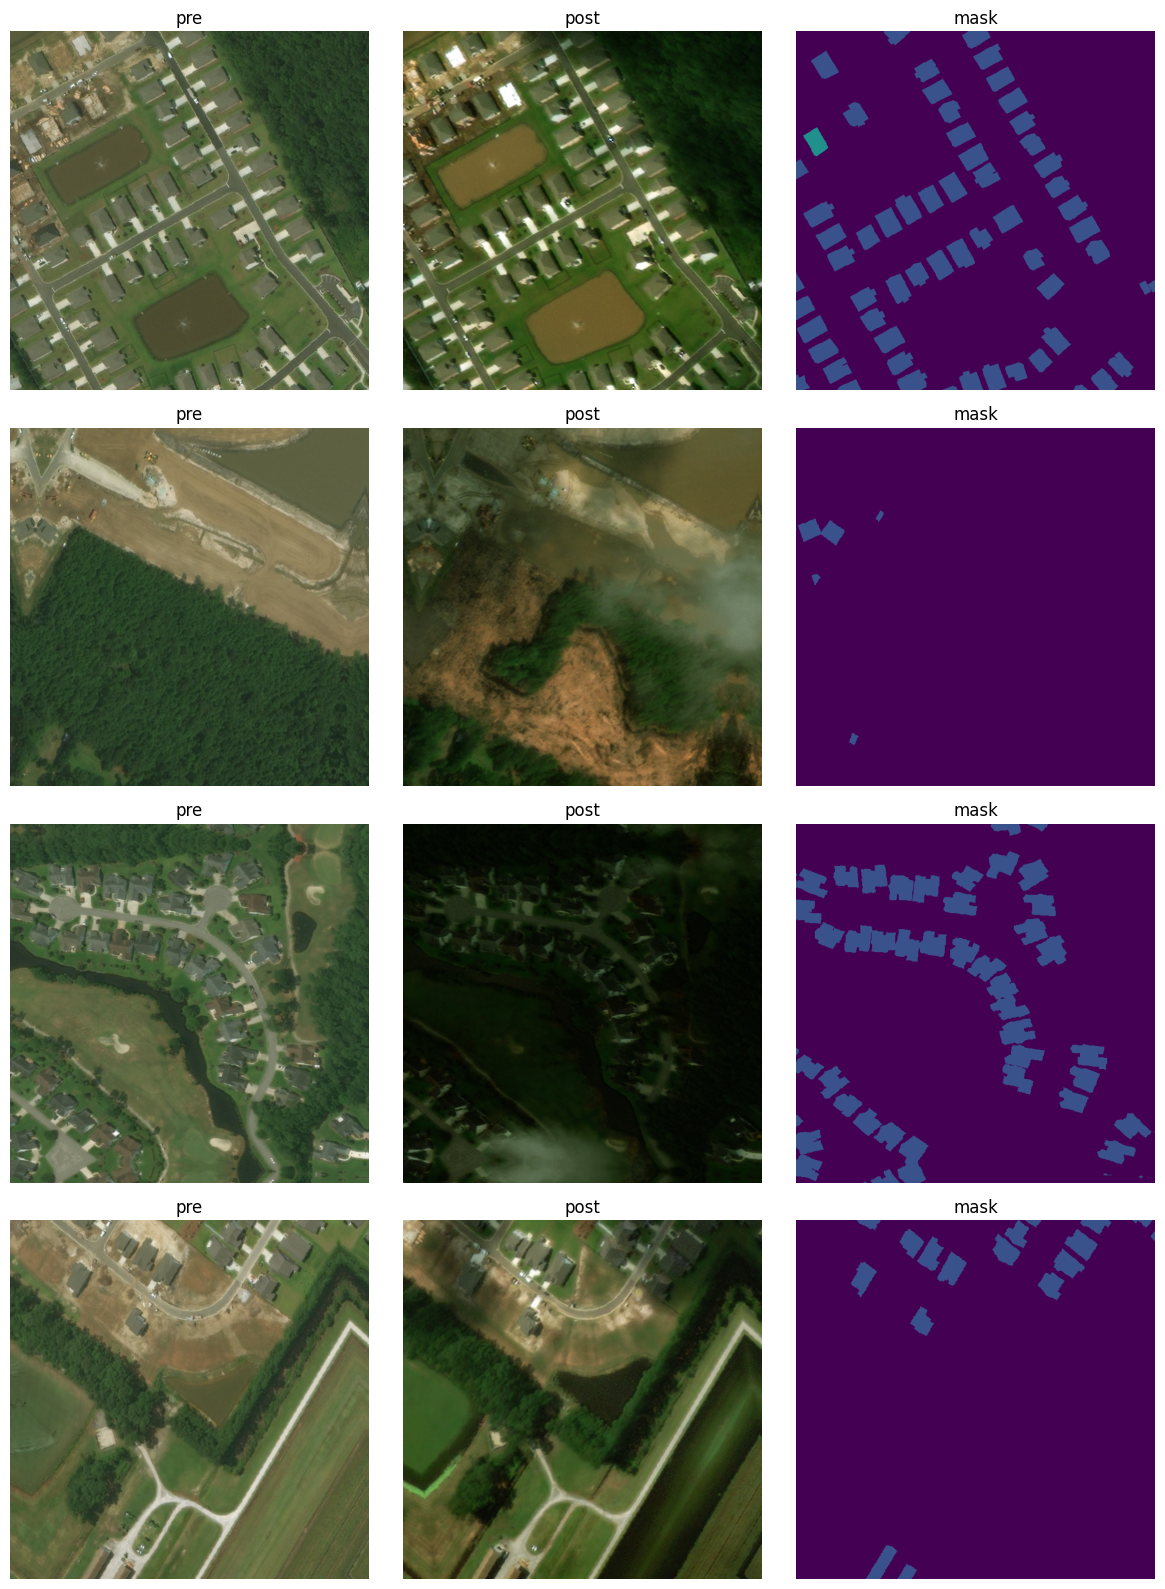

In [ ]:
def show_batch(dataset, n=4):
    fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))
    for i in range(n):
        pre, post, mask = dataset[i]
        pre = pre.permute(1, 2, 0).numpy()
        post = post.permute(1, 2, 0).numpy()
        pre = (pre * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
        post = (post * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
        axes[i,0].imshow(pre)
        axes[i,0].set_title('pre')
        axes[i,1].imshow(post)
        axes[i,1].set_title('post')
        axes[i,2].imshow(mask.numpy(), vmin=0, vmax=4)
        axes[i,2].set_title('mask')
        for j in range(3):
            axes[i,j].axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_ds)

## **Damage Segmentation Architecture**

Define the Siamese EfficientNet-based bi-temporal model used for dense 5-class damage prediction.

In [ ]:
class SiameseEfficientUNet(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.encoder = timm.create_model(
            "efficientnet_b1",
            pretrained=True,
            features_only=True,
            in_chans=3,
            out_indices=(0, 1, 2, 3, 4)
        )

        enc_channels = self.encoder.feature_info.channels()

        fused_channels = [3 * c for c in enc_channels]

        self.center = ConvBlock(fused_channels[-1], 256)
        self.up4 = UpBlock(256, fused_channels[3], 192)
        self.up3 = UpBlock(192, fused_channels[2], 128)
        self.up2 = UpBlock(128, fused_channels[1], 96)
        self.up1 = UpBlock(96, fused_channels[0], 64)

        self.head = nn.Conv2d(64, num_classes, kernel_size=1)

    def fuse(self, f1, f2):
        return torch.cat([f1, f2, torch.abs(f2 - f1)], dim=1)

    def forward(self, pre, post):
        pre_feats = self.encoder(pre)
        post_feats = self.encoder(post)

        fused = [self.fuse(a, b) for a, b in zip(pre_feats, post_feats)]

        x = self.center(fused[-1])
        x = self.up4(x, fused[3])
        x = self.up3(x, fused[2])
        x = self.up2(x, fused[1])
        x = self.up1(x, fused[0])
        x = self.head(x)

        if x.shape[-2:] != pre.shape[-2:]:
            x = F.interpolate(x, size=pre.shape[-2:], mode="bilinear", align_corners=False)

        return x

## **Damage Model Initialization**

Compute multi-class loss weights, initialize the Siamese damage model, and load encoder weights from the localization checkpoint.

In [ ]:
def get_class_weights_from_paths(mask_paths):
    counts = np.zeros(NUM_CLASSES, dtype=np.float64)

    for mask_path in mask_paths:
        mask = np.array(Image.open(mask_path))
        vals, freqs = np.unique(mask, return_counts=True)
        counts[vals] += freqs

    weights = counts.sum() / (NUM_CLASSES * counts)
    weights = weights / weights.sum() * NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float32)

class_weights = get_class_weights_from_paths(train_df["mask_path"].tolist()).to(DEVICE)
print("Class weights:", class_weights)

Class weights: tensor([0.0065, 0.1264, 2.4291, 0.8842, 1.5539], device='cuda:0')


In [ ]:
model = SiameseEfficientUNet(num_classes=NUM_CLASSES).to(DEVICE)

loc_model_for_init = LocalizationEfficientUNet(num_classes=2).to(DEVICE)
loc_ckpt = torch.load("/content/best_localization_b1.pth", map_location=DEVICE)
loc_model_for_init.load_state_dict(loc_ckpt)

model.encoder.load_state_dict(loc_model_for_init.encoder.state_dict())

print("Loaded localization encoder weights into Siamese model.")

encoder_params = list(model.encoder.parameters())
decoder_params = (
    list(model.center.parameters()) +
    list(model.up4.parameters()) +
    list(model.up3.parameters()) +
    list(model.up2.parameters()) +
    list(model.up1.parameters()) +
    list(model.head.parameters())
)

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 2e-5},
    {'params': decoder_params, 'lr': 1e-4}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler('cuda')

Loaded localization encoder weights into Siamese model.


In [ ]:
def run_train_epoch(loader):
    model.train()

    total_loss = 0.0
    seen = 0
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    pbar = tqdm(loader, desc="Train", leave=False)

    for pre, post, mask in pbar:
        pre = pre.to(DEVICE, non_blocking=True)
        post = post.to(DEVICE, non_blocking=True)
        mask = mask.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
            logits = model(pre, post).float()
            loss = loss_fn(logits, mask)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = pre.size(0)
        total_loss += loss.item() * bs
        seen += bs

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy().ravel()
        targets = mask.detach().cpu().numpy().ravel()
        cm += confusion_matrix(targets, preds, labels=list(range(NUM_CLASSES)))

        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = total_loss / seen
    macro_f1, damage_f1, _ = macro_f1_from_cm(cm)
    miou, _ = miou_from_cm(cm)

    return {
        "loss": epoch_loss,
        "macro_f1": macro_f1,
        "damage_f1": damage_f1,
        "miou": miou,
        "cm": cm
    }

## **Post-Processing Helpers**

Define light post-processing used to clean predicted damage masks before final evaluation.

In [ ]:
def remove_small_components_per_class(mask, min_sizes=None):
    if min_sizes is None:
        min_sizes = {1: 20, 2: 20, 3: 15, 4: 10}

    out = np.zeros_like(mask)

    for cls in [1, 2, 3, 4]:
        binary = (mask == cls).astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

        for i in range(1, num_labels):
            area = stats[i, cv2.CC_STAT_AREA]
            if area >= min_sizes.get(cls, 0):
                out[labels == i] = cls

    return out

def postprocess_mask(mask, do_remove_small=True):
    out = mask.copy()
    if do_remove_small:
        out = remove_small_components_per_class(out)
    return out

## **Test-Time Augmentation**

Define the test-time augmentation routine used during full-tile inference.

In [ ]:
def predict_with_tta(model, pre, post):
    model.eval()

    logits_sum = 0.0
    n = 0

    # original
    logits = model(pre, post)
    logits_sum += logits
    n += 1

    # horizontal flip
    pre_h = torch.flip(pre, dims=[3])
    post_h = torch.flip(post, dims=[3])
    logits_h = model(pre_h, post_h)
    logits_h = torch.flip(logits_h, dims=[3])
    logits_sum += logits_h
    n += 1

    # vertical flip
    pre_v = torch.flip(pre, dims=[2])
    post_v = torch.flip(post, dims=[2])
    logits_v = model(pre_v, post_v)
    logits_v = torch.flip(logits_v, dims=[2])
    logits_sum += logits_v
    n += 1

    # 180 rotation
    pre_r = torch.flip(pre, dims=[2, 3])
    post_r = torch.flip(post, dims=[2, 3])
    logits_r = model(pre_r, post_r)
    logits_r = torch.flip(logits_r, dims=[2, 3])
    logits_sum += logits_r
    n += 1

    logits_avg = logits_sum / n
    return logits_avg

## **Tiled Inference Helpers**

Define the overlap-and-blend inference pipeline used to generate dense full-tile predictions from the trained model.

In [ ]:
BEST_USE_TTA = True
BEST_POSTPROC = dict(do_remove_small=True)
BEST_TILE_SIZE = TRAIN_PATCH_SIZE
BEST_STRIDE = TRAIN_PATCH_SIZE // 2

def get_tile_starts(size, tile_size, stride):
    starts = list(range(0, size - tile_size + 1, stride))
    if starts[-1] != size - tile_size:
        starts.append(size - tile_size)
    return starts

def make_blend_window(tile_size):
    w = torch.hann_window(tile_size, periodic=False)
    window = torch.outer(w, w)
    window = window / window.max()
    return window.clamp_min(1e-3)

_blend_window_cache = {}

def get_blend_window(tile_size):
    if tile_size not in _blend_window_cache:
        _blend_window_cache[tile_size] = make_blend_window(tile_size).to(DEVICE)
    return _blend_window_cache[tile_size]

def predict_patch_logits(model, pre_patch, post_patch, use_tta=False):
    if use_tta:
        return predict_with_tta(model, pre_patch, post_patch)
    return model(pre_patch, post_patch)

def predict_full_logits_tiled(model, pre_tensor, post_tensor, tile_size=None, stride=None, use_tta=False):
    if tile_size is None:
        tile_size = BEST_TILE_SIZE
    if stride is None:
        stride = BEST_STRIDE

    model.eval()

    pre_tensor = pre_tensor.to(DEVICE)
    post_tensor = post_tensor.to(DEVICE)

    _, H, W = pre_tensor.shape
    logits_sum = torch.zeros((NUM_CLASSES, H, W), device=DEVICE)
    weight_sum = torch.zeros((1, H, W), device=DEVICE)

    ys = get_tile_starts(H, tile_size, stride)
    xs = get_tile_starts(W, tile_size, stride)

    blend_window = get_blend_window(tile_size)

    with torch.no_grad():
        for y in ys:
            for x in xs:
                pre_patch = pre_tensor[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)
                post_patch = post_tensor[:, y:y+tile_size, x:x+tile_size].unsqueeze(0)

                logits = predict_patch_logits(
                    model,
                    pre_patch,
                    post_patch,
                    use_tta=use_tta
                ).squeeze(0)

                logits_sum[:, y:y+tile_size, x:x+tile_size] += logits * blend_window
                weight_sum[:, y:y+tile_size, x:x+tile_size] += blend_window

    logits_avg = logits_sum / weight_sum.clamp_min(1e-6)
    return logits_avg

def get_pred_map_best_full(model, pre_tensor, post_tensor, tile_size=None, stride=None):
    if tile_size is None:
        tile_size = BEST_TILE_SIZE
    if stride is None:
        stride = BEST_STRIDE

    logits_full = predict_full_logits_tiled(
        model,
        pre_tensor,
        post_tensor,
        tile_size=tile_size,
        stride=stride,
        use_tta=BEST_USE_TTA
    )
    pred = torch.argmax(logits_full, dim=0).cpu().numpy()
    pred = postprocess_mask(pred, **BEST_POSTPROC)
    return pred

## **Full-Tile Evaluation**

Evaluate the model on complete tiles and report pixel-level metrics such as mIoU, macro-F1, and damage-F1.

In [ ]:
def evaluate_full_tiles(loader, use_tta=False, stride=256, apply_postproc=False):
    model.eval()

    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    total_loss = 0.0
    seen = 0

    with torch.no_grad():
        for pre, post, mask in tqdm(loader, desc="Full-tile eval"):
            pre = pre.squeeze(0)
            post = post.squeeze(0)
            mask = mask.squeeze(0)

            logits_full = predict_full_logits_tiled(
                model,
                pre,
                post,
                tile_size=BEST_TILE_SIZE,
                stride=BEST_STRIDE,
                use_tta=use_tta
            )

            loss = loss_fn(
                logits_full.unsqueeze(0),
                mask.unsqueeze(0).to(DEVICE)
            )

            total_loss += loss.item()
            seen += 1

            pred = torch.argmax(logits_full, dim=0).cpu().numpy()

            if apply_postproc:
                pred = postprocess_mask(pred, **BEST_POSTPROC)

            cm += confusion_matrix(
                mask.cpu().numpy().ravel(),
                pred.ravel(),
                labels=list(range(NUM_CLASSES))
            )

    macro_f1, damage_f1, per_class_f1 = macro_f1_from_cm(cm)
    miou, per_class_iou = miou_from_cm(cm)

    metrics_df = pd.DataFrame({
        "class": CLASS_NAMES,
        "IoU": per_class_iou,
        "F1": per_class_f1
    })

    summary_df = pd.DataFrame({
        "val_loss": [total_loss / seen],
        "macro_f1": [macro_f1],
        "damage_f1": [damage_f1],
        "miou": [miou]
    })

    return cm, metrics_df, summary_df

## **Train Bi-Temporal Damage Model**

Train the final bi-temporal segmentation model using damage-aware crop selection and monitor pixel-level validation metrics.

In [ ]:
best_val = -1
best_epoch = -1
epochs_no_improve = 0
early_stop_patience = 6

history = {
    "train_loss": [],
    "train_miou": [],
    "train_macro_f1": [],
    "train_damage_f1": [],
    "val_loss": [],
    "val_macro_f1": [],
    "val_damage_f1": [],
    "val_miou": [],
    "enc_lr": [],
    "dec_lr": []
}

save_path = "/content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth"

for epoch in range(EPOCHS):
    train_metrics = run_train_epoch(train_loader)

    _, _, val_summary = evaluate_full_tiles(
        val_full_loader,
        use_tta=False,
        stride=CROP_SIZE // 2,
        apply_postproc=False
    )

    val_loss = float(val_summary["val_loss"].iloc[0])
    val_macro_f1 = float(val_summary["macro_f1"].iloc[0])
    val_damage_f1 = float(val_summary["damage_f1"].iloc[0])
    val_miou = float(val_summary["miou"].iloc[0])

    scheduler.step(val_damage_f1)

    enc_lr = optimizer.param_groups[0]["lr"]
    dec_lr = optimizer.param_groups[1]["lr"]

    history["train_loss"].append(train_metrics["loss"])
    history["train_miou"].append(train_metrics["miou"])
    history["train_macro_f1"].append(train_metrics["macro_f1"])
    history["train_damage_f1"].append(train_metrics["damage_f1"])
    history["val_loss"].append(val_loss)
    history["val_macro_f1"].append(val_macro_f1)
    history["val_damage_f1"].append(val_damage_f1)
    history["val_miou"].append(val_miou)

    history["enc_lr"].append(enc_lr)
    history["dec_lr"].append(dec_lr)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"enc_lr={enc_lr:.2e} | dec_lr={dec_lr:.2e} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"train_mIoU={train_metrics['miou']:.4f} | "
        f"train_macro_F1={train_metrics['macro_f1']:.4f} | "
        f"train_damage_F1={train_metrics['damage_f1']:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_miou:.4f} | "
        f"val_macro_F1={val_macro_f1:.4f} | "
        f"val_damage_F1={val_damage_f1:.4f} "
    )

    if val_damage_f1 > best_val:
        best_val = val_damage_f1
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model to {save_path}")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}. Best epoch was {best_epoch}.")
        break

print(f"Training finished. Best val_damage_f1 = {best_val:.4f} at epoch {best_epoch}.")

Epoch 01/35 | enc_lr=2.00e-05 | dec_lr=1.00e-04 | train_loss=0.8775 | train_mIoU=0.1753 | train_macro_F1=0.2425 | train_damage_F1=0.0286 | val_loss=0.8646 | val_mIoU=0.2596 | val_macro_F1=0.3181 | val_damage_F1=0.0226 
Saved best model to /content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth


Epoch 02/35 | enc_lr=2.00e-05 | dec_lr=1.00e-04 | train_loss=0.8062 | train_mIoU=0.2930 | train_macro_F1=0.3689 | train_damage_F1=0.0925 | val_loss=0.8365 | val_mIoU=0.3249 | val_macro_F1=0.3955 | val_damage_F1=0.0996 
Saved best model to /content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth


Epoch 03/35 | enc_lr=2.00e-05 | dec_lr=1.00e-04 | train_loss=0.7614 | train_mIoU=0.3344 | train_macro_F1=0.4186 | train_damage_F1=0.1483 | val_loss=0.8137 | val_mIoU=0.3317 | val_macro_F1=0.3924 | val_damage_F1=0.0815 


Epoch 04/35 | enc_lr=2.00e-05 | dec_lr=1.00e-04 | train_loss=0.7250 | train_mIoU=0.3697 | train_macro_F1=0.4606 | train_damage_F1=0.2022 | val_loss=0.8008 | val_mIoU=0.3463 | val_macro_F1=0.4177 | val_damage_F1=0.1292 
Saved best model to /content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth


Epoch 05/35 | enc_lr=2.00e-05 | dec_lr=1.00e-04 | train_loss=0.6809 | train_mIoU=0.4266 | train_macro_F1=0.5326 | train_damage_F1=0.3099 | val_loss=0.7844 | val_mIoU=0.3822 | val_macro_F1=0.4617 | val_damage_F1=0.1860 
Saved best model to /content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth


...

Epoch 28/35 | enc_lr=1.00e-05 | dec_lr=5.00e-05 | train_loss=0.3242 | train_mIoU=0.6922 | train_macro_F1=0.8070 | train_damage_F1=0.7365 | val_loss=0.7138 | val_mIoU=0.5743 | val_macro_F1=0.6921 | val_damage_F1=0.5485 


Epoch 29/35 | enc_lr=5.00e-06 | dec_lr=2.50e-05 | train_loss=0.3407 | train_mIoU=0.6797 | train_macro_F1=0.7958 | train_damage_F1=0.7189 | val_loss=0.7121 | val_mIoU=0.5755 | val_macro_F1=0.6939 | val_damage_F1=0.5536 


Epoch 30/35 | enc_lr=5.00e-06 | dec_lr=2.50e-05 | train_loss=0.3431 | train_mIoU=0.6881 | train_macro_F1=0.8029 | train_damage_F1=0.7296 | val_loss=0.7152 | val_mIoU=0.5853 | val_macro_F1=0.7069 | val_damage_F1=0.5696 


Epoch 31/35 | enc_lr=5.00e-06 | dec_lr=2.50e-05 | train_loss=0.3275 | train_mIoU=0.6949 | train_macro_F1=0.8090 | train_damage_F1=0.7390 | val_loss=0.7141 | val_mIoU=0.5820 | val_macro_F1=0.7014 | val_damage_F1=0.5631 


Epoch 32/35 | enc_lr=2.50e-06 | dec_lr=1.25e-05 | train_loss=0.3310 | train_mIoU=0.6932 | train_macro_F1=0.8071 | train_damage_F1=0.7361 | val_loss=0.7090 | val_mIoU=0.5810 | val_macro_F1=0.7002 | val_damage_F1=0.5620 
Early stopping triggered at epoch 32. Best epoch was 26.
Training finished. Best val_damage_f1 = 0.5705 at epoch 26.


In [ ]:
SAVE_PATH = Path("/content/drive/MyDrive/xBD_project/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_V1.pth")
torch.save(model.state_dict(), SAVE_PATH)

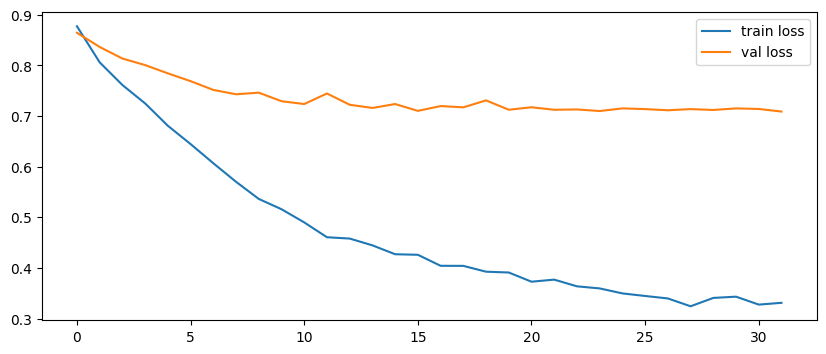

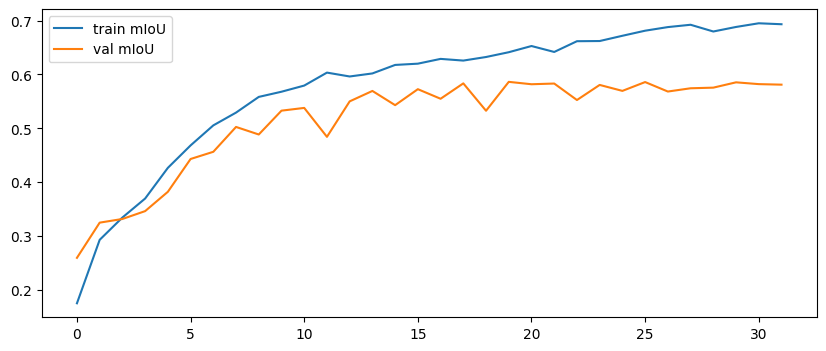

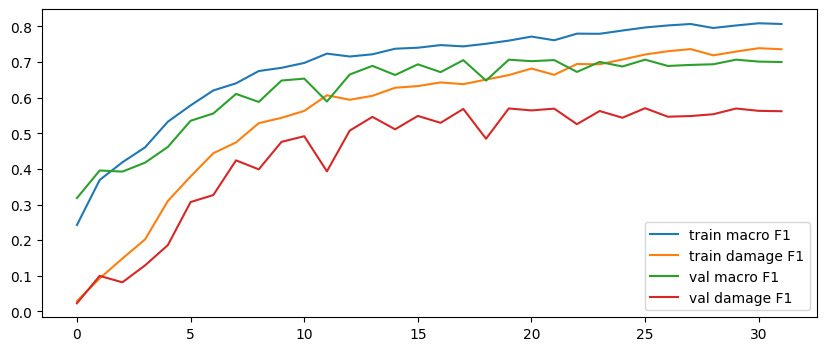

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["train_miou"], label="train mIoU")
plt.plot(history["val_miou"], label="val mIoU")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history["train_macro_f1"], label="train macro F1")
plt.plot(history["train_damage_f1"], label="train damage F1")
plt.plot(history["val_macro_f1"], label="val macro F1")
plt.plot(history["val_damage_f1"], label="val damage F1")
plt.legend()
plt.show()

## **Evaluate Pixel-Level Performance**

Report final full-tile test performance and visualize the pixel-level confusion matrix.

In [ ]:
model.load_state_dict(torch.load("/content/SiameseUNet_EfficientNet_B1_cross_disaster_locpretrained_crop_best.pth", map_location=DEVICE))

cm, metrics_df, summary_df = evaluate_full_tiles(
    test_full_loader,
    use_tta=BEST_USE_TTA,
    stride=BEST_STRIDE,
    apply_postproc=True
)

print(f"Test mIoU: {summary_df['miou'].iloc[0]:.4f}")
print(f"Test macro F1: {summary_df['macro_f1'].iloc[0]:.4f}")
print(f"Test damage F1: {summary_df['damage_f1'].iloc[0]:.4f}")

metrics_df

Test mIoU: 0.3201
Test macro F1: 0.3856
Test damage F1: 0.1150


,class,IoU,F1
0,background,0.978224,0.988992
1,no-damage,0.422302,0.593829
2,minor-damage,0.018083,0.035523
3,major-damage,0.003707,0.007387
4,destroyed,0.178014,0.302228


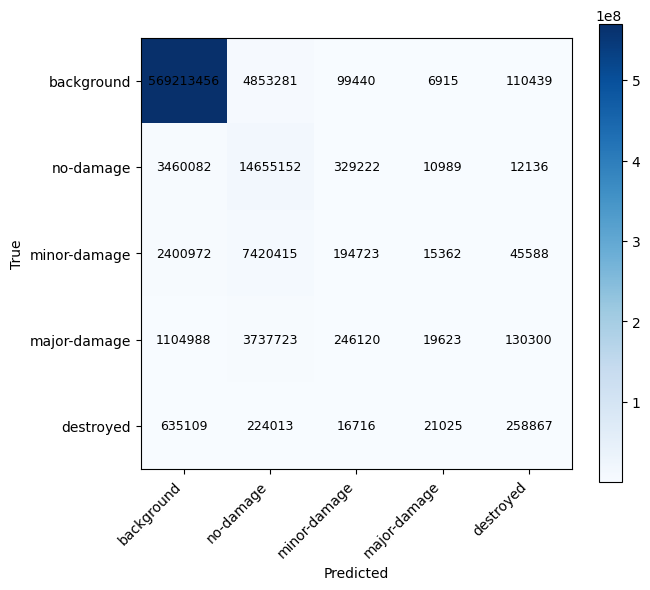

In [ ]:
plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black", fontsize=9)
plt.tight_layout()
plt.show()

## **Qualitative Full-Tile Predictions**

Visualize predicted damage masks on full tiles and compare them against the ground truth.

In [ ]:
damage_colors = ["black", "white", "yellow", "orange", "red"]
damage_cmap = ListedColormap(damage_colors)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def show_predictions(dataset, n=3):
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(14, 4*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for i in range(n):
            pre, post, mask = dataset[i]

            pred = get_pred_map_best_full(model, pre, post)

            pre_img = pre.permute(1, 2, 0).numpy()
            post_img = post.permute(1, 2, 0).numpy()

            pre_img = (pre_img * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
            post_img = (post_img * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)

            axes[i, 0].imshow(pre_img)
            axes[i, 0].set_title("Pre-disaster")

            axes[i, 1].imshow(post_img)
            axes[i, 1].set_title("Post-disaster")

            axes[i, 2].imshow(mask.numpy(), cmap=damage_cmap, vmin=0, vmax=4)
            axes[i, 2].set_title("Ground Truth")

            im = axes[i, 3].imshow(pred, cmap=damage_cmap, vmin=0, vmax=4)
            axes[i, 3].set_title("Prediction")

            for j in range(4):
                axes[i, j].axis("off")

    plt.tight_layout()
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation="vertical", shrink=0.75)
    cbar.set_ticks(np.arange(len(CLASS_NAMES)))
    cbar.set_ticklabels(CLASS_NAMES)
    plt.show()

show_predictions(test_full_ds, n=8)

Output hidden; open in https://colab.research.google.com to view.

# **Building-Level Assessment from Pixel Predictions**

Convert the dense damage predictions into one damage label per building using the xBD building polygons.

## **Load Building Polygon Annotations**

Load xBD building polygons and remap label paths for building-level evaluation.

In [ ]:
LABELS_ROOT = DRIVE_PROJECT_ROOT / "labels"

def to_colab_label_path(p):
    filename = p.split("\\")[-1]   # extract file name from Windows path
    return str(LABELS_ROOT / filename)

df["pre_label_path"] = df["pre_label_path"].apply(to_colab_label_path)
df["post_label_path"] = df["post_label_path"].apply(to_colab_label_path)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

print(test_df[["sample_id", "post_label_path"]].head())
print("Example JSON exists:", Path(test_df.loc[0, "post_label_path"]).exists())

                    sample_id  \
0  hurricane-matthew_00000000   
1  hurricane-matthew_00000001   
2  hurricane-matthew_00000002   
3  hurricane-matthew_00000003   
4  hurricane-matthew_00000004   

                                     post_label_path  
0  /content/xbd_work/train/labels/hurricane-matth...  
1  /content/xbd_work/train/labels/hurricane-matth...  
2  /content/xbd_work/train/labels/hurricane-matth...  
3  /content/xbd_work/train/labels/hurricane-matth...  
4  /content/xbd_work/train/labels/hurricane-matth...  
Example JSON exists: True


In [ ]:
print(test_df.loc[0, "post_label_path"])

/content/xbd_work/train/labels/hurricane-matthew_00000000_post_disaster.json


In [ ]:
DAMAGE_MAP = {
    "no-damage": 1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed": 4
}

def parse_wkt_polygon(wkt_str):
    coords_text = re.findall(r"\(\((.*)\)\)", wkt_str)[0]
    points = []
    for pair in coords_text.split(","):
        x, y = pair.strip().split()
        points.append((float(x), float(y)))
    return np.array(points, dtype=np.float32)

def load_post_buildings_from_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    buildings = []
    for feat in data["features"]["xy"]:
        props = feat["properties"]
        if props.get("feature_type") != "building":
            continue
        subtype = props.get("subtype")
        if subtype not in DAMAGE_MAP:
            continue

        poly = parse_wkt_polygon(feat["wkt"])
        uid = props.get("uid")
        label = DAMAGE_MAP[subtype]

        buildings.append({
            "uid": uid,
            "polygon": poly,
            "label": label
        })

    return buildings

## **Polygon-to-Mask Conversion**

Convert each building polygon into a binary mask aligned with the prediction grid.

In [ ]:
def polygon_to_mask(polygon_xy, out_h, out_w, scale_x=1.0, scale_y=1.0):
    poly = polygon_xy.copy()
    poly[:, 0] *= scale_x
    poly[:, 1] *= scale_y

    poly = np.round(poly).astype(np.int32)
    poly[:, 0] = np.clip(poly[:, 0], 0, out_w - 1)
    poly[:, 1] = np.clip(poly[:, 1], 0, out_h - 1)

    mask = np.zeros((out_h, out_w), dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)
    return mask

## **Aggregate Pixel Predictions Per Building**

Convert dense damage predictions into one label per building by aggregating predicted classes inside each building mask.

In [ ]:
def predict_building_label(pred_map, building_mask, ignore_background=True, fallback_class=1):
    pixels = pred_map[building_mask == 1]

    if ignore_background:
        pixels = pixels[pixels != 0]

    used_fallback = False
    if len(pixels) == 0:
        used_fallback = True
        return fallback_class, used_fallback

    pred = Counter(pixels.tolist()).most_common(1)[0][0]
    return pred, used_fallback

## **Full building-level evaluation for one tile**

In [ ]:
all_true = []
all_pred = []
total_fallbacks = 0
fallback_true_labels = []

for i in range(len(test_full_ds)):
    pre, post, mask = test_full_ds[i]

    pred_map = get_pred_map_best_full(model, pre, post)

    json_path = test_df.loc[i, "post_label_path"]
    buildings = load_post_buildings_from_json(json_path)

    original_h = int(test_df.loc[i, "height"]) if "height" in test_df.columns else 1024
    original_w = int(test_df.loc[i, "width"]) if "width" in test_df.columns else 1024

    h, w = pred_map.shape
    scale_x = w / original_w
    scale_y = h / original_h

    for b in buildings:
        bmask = polygon_to_mask(
            b["polygon"],
            h,
            w,
            scale_x=scale_x,
            scale_y=scale_y
        )

        pixels = pred_map[bmask == 1]
        pixels_no_bg = pixels[pixels != 0]

        if len(pixels_no_bg) == 0:
            pred_label = 1   # fallback_class
            total_fallbacks += 1
            fallback_true_labels.append(b["label"])
        else:
            pred_label = Counter(pixels_no_bg.tolist()).most_common(1)[0][0]

        all_true.append(b["label"])
        all_pred.append(pred_label)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

print("Number of buildings evaluated:", len(all_true))
print("Fallback count:", total_fallbacks)
print("Fallback rate:", total_fallbacks / max(len(all_true), 1))
print("Fallbacks by true class:", Counter(fallback_true_labels))

cm_building_damage = confusion_matrix(all_true, all_pred, labels=[1, 2, 3, 4])

print(classification_report(
    all_true,
    all_pred,
    labels=[1, 2, 3, 4],
    target_names=CLASS_NAMES[1:],
    digits=4,
    zero_division=0
))

Number of buildings evaluated: 35609
Fallback count: 6036
Fallback rate: 0.16950770872532225
Fallbacks by true class: Counter({1: 2346, 2: 1616, 4: 1506, 3: 568})
              precision    recall  f1-score   support

   no-damage     0.4989    0.9706    0.6591     17103
minor-damage     0.3378    0.0235    0.0439     11755
major-damage     0.1789    0.0044    0.0086      3847
   destroyed     0.5858    0.2879    0.3861      2904

    accuracy                         0.4979     35609
   macro avg     0.4004    0.3216    0.2744     35609
weighted avg     0.4183    0.4979    0.3635     35609



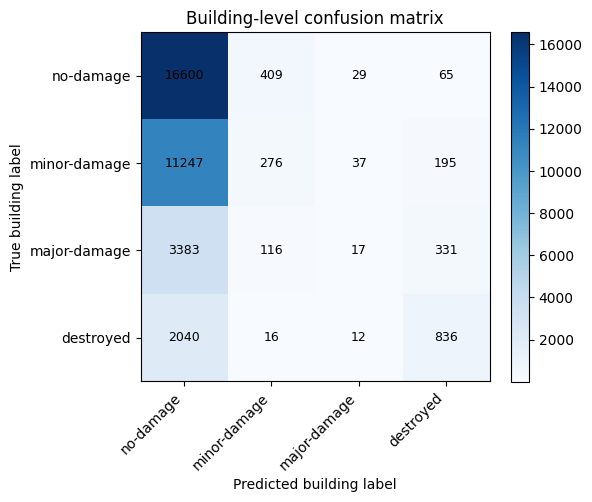

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(cm_building_damage, cmap="Blues")
plt.xticks(range(4), CLASS_NAMES[1:], rotation=45, ha="right")
plt.yticks(range(4), CLASS_NAMES[1:])
plt.xlabel("Predicted building label")
plt.ylabel("True building label")
plt.title("Building-level confusion matrix")
plt.colorbar()

for i in range(4):
    for j in range(4):
        plt.text(j, i, int(cm_building_damage[i, j]), ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()